# Time Series Visualization Analysis

This notebook provides comprehensive visualizations for time series data, including trend analysis, seasonality patterns, and interactive plots.

## 1. Load and Prepare Time Series Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)

df = pd.read_csv('../data/train.csv')

# Load data (reusing the already loaded dataframe)
print(f"📊 Dataset Shape: {df.shape}")
print(f"📅 Date Range: {df['Tahun'].min()} to {df['Tahun'].max()}")
print(f"🌡️ Temperature Range: {df['Suhu_Rata_Rata_C'].min():.2f}°C to {df['Suhu_Rata_Rata_C'].max():.2f}°C")

# Check if data is sorted by time
if not df['Tahun'].is_monotonic_increasing:
    print("⚠️ Sorting data by year...")
    df = df.sort_values('Tahun').reset_index(drop=True)
else:
    print("✅ Data is already sorted by year")

# Check for missing values in key columns
print(f"\n🔍 Missing Values:")
print(df[['Tahun', 'Suhu_Rata_Rata_C']].isnull().sum())

# Display sample
display(df[['Tahun', 'Suhu_Rata_Rata_C', 'Nama_Negara', 'Wilayah']].head(10))

📊 Dataset Shape: (8000, 15)
📅 Date Range: 1990 to 2024
🌡️ Temperature Range: -4.99°C to 35.00°C
⚠️ Sorting data by year...

🔍 Missing Values:
Tahun               0
Suhu_Rata_Rata_C    0
dtype: int64


,Tahun,Suhu_Rata_Rata_C,Nama_Negara,Wilayah
0,1990,21.65,Argentina,Patagonia
1,1990,3.46,Russia,Volga
2,1990,24.42,Russia,Northwestern
3,1990,4.23,China,East
4,1990,7.19,Russia,Northwestern
5,1990,30.70,China,Central
6,1990,2.53,Brazil,Northeast
7,1990,23.20,France,'Provence-Alpes-Cote d’Azur'
8,1990,30.73,Australia,'New South Wales'
9,1990,19.73,Brazil,South


## 2. Basic Time Series Line Plot

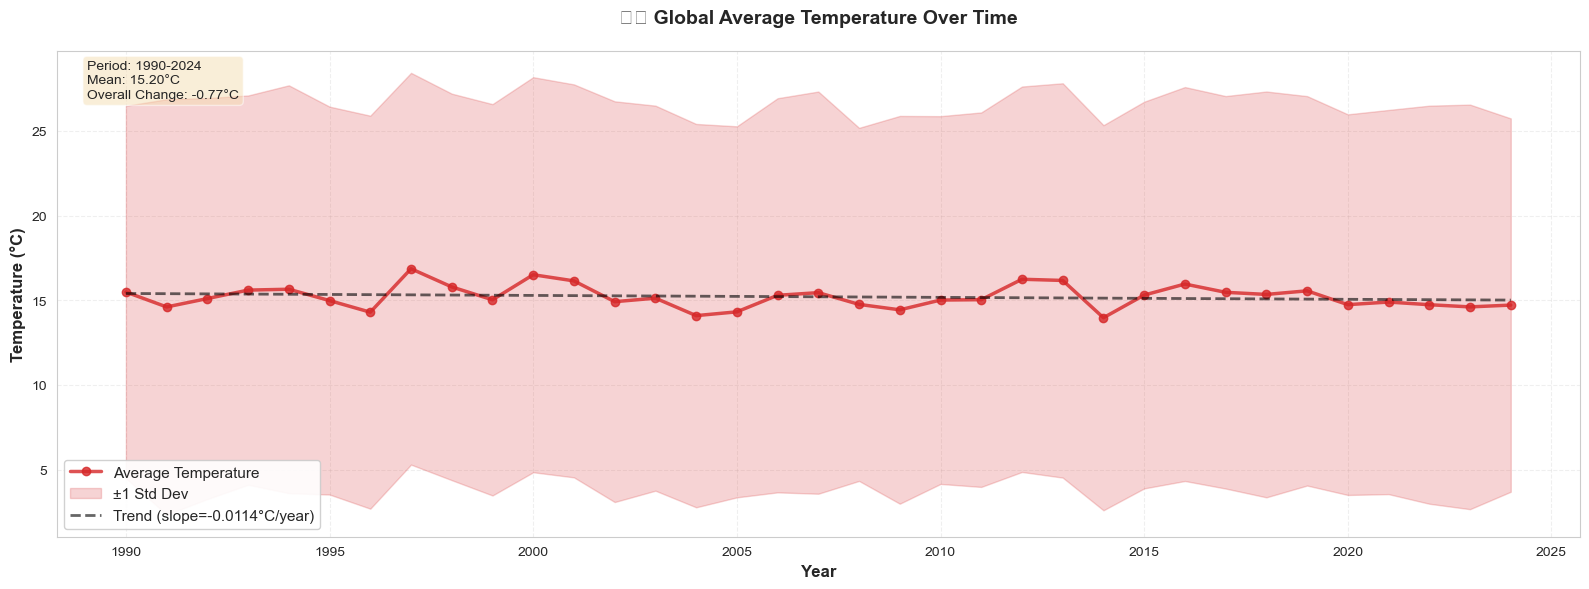

📈 Temperature increased by -0.77°C over 34 years
📊 Average annual change: -0.0114°C/year


In [2]:
# Aggregate temperature by year for cleaner visualization
yearly_temp = df.groupby('Tahun')['Suhu_Rata_Rata_C'].agg(['mean', 'std', 'count']).reset_index()

# Create basic line plot
fig, ax = plt.subplots(figsize=(16, 6))

# Main line plot
ax.plot(yearly_temp['Tahun'], yearly_temp['mean'], 
        'o-', linewidth=2.5, markersize=6, 
        color='#d62728', label='Average Temperature', alpha=0.8)

# Add confidence band (±1 std)
ax.fill_between(yearly_temp['Tahun'], 
                 yearly_temp['mean'] - yearly_temp['std'],
                 yearly_temp['mean'] + yearly_temp['std'],
                 alpha=0.2, color='#d62728', label='±1 Std Dev')

# Add trend line
z = np.polyfit(yearly_temp['Tahun'], yearly_temp['mean'], 1)
p = np.poly1d(z)
ax.plot(yearly_temp['Tahun'], p(yearly_temp['Tahun']), 
        '--', linewidth=2, color='black', alpha=0.6,
        label=f'Trend (slope={z[0]:.4f}°C/year)')

# Styling
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax.set_title('🌡️ Global Average Temperature Over Time', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

# Add statistics box
textstr = f'Period: {yearly_temp["Tahun"].min()}-{yearly_temp["Tahun"].max()}\n'
textstr += f'Mean: {yearly_temp["mean"].mean():.2f}°C\n'
textstr += f'Overall Change: {yearly_temp["mean"].iloc[-1] - yearly_temp["mean"].iloc[0]:.2f}°C'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print(f"📈 Temperature increased by {yearly_temp['mean'].iloc[-1] - yearly_temp['mean'].iloc[0]:.2f}°C over {yearly_temp['Tahun'].max() - yearly_temp['Tahun'].min()} years")
print(f"📊 Average annual change: {z[0]:.4f}°C/year")

## 3. Multiple Time Series Comparison

🌍 Analyzing top countries by data volume...
🗺️ Analyzing top regions...


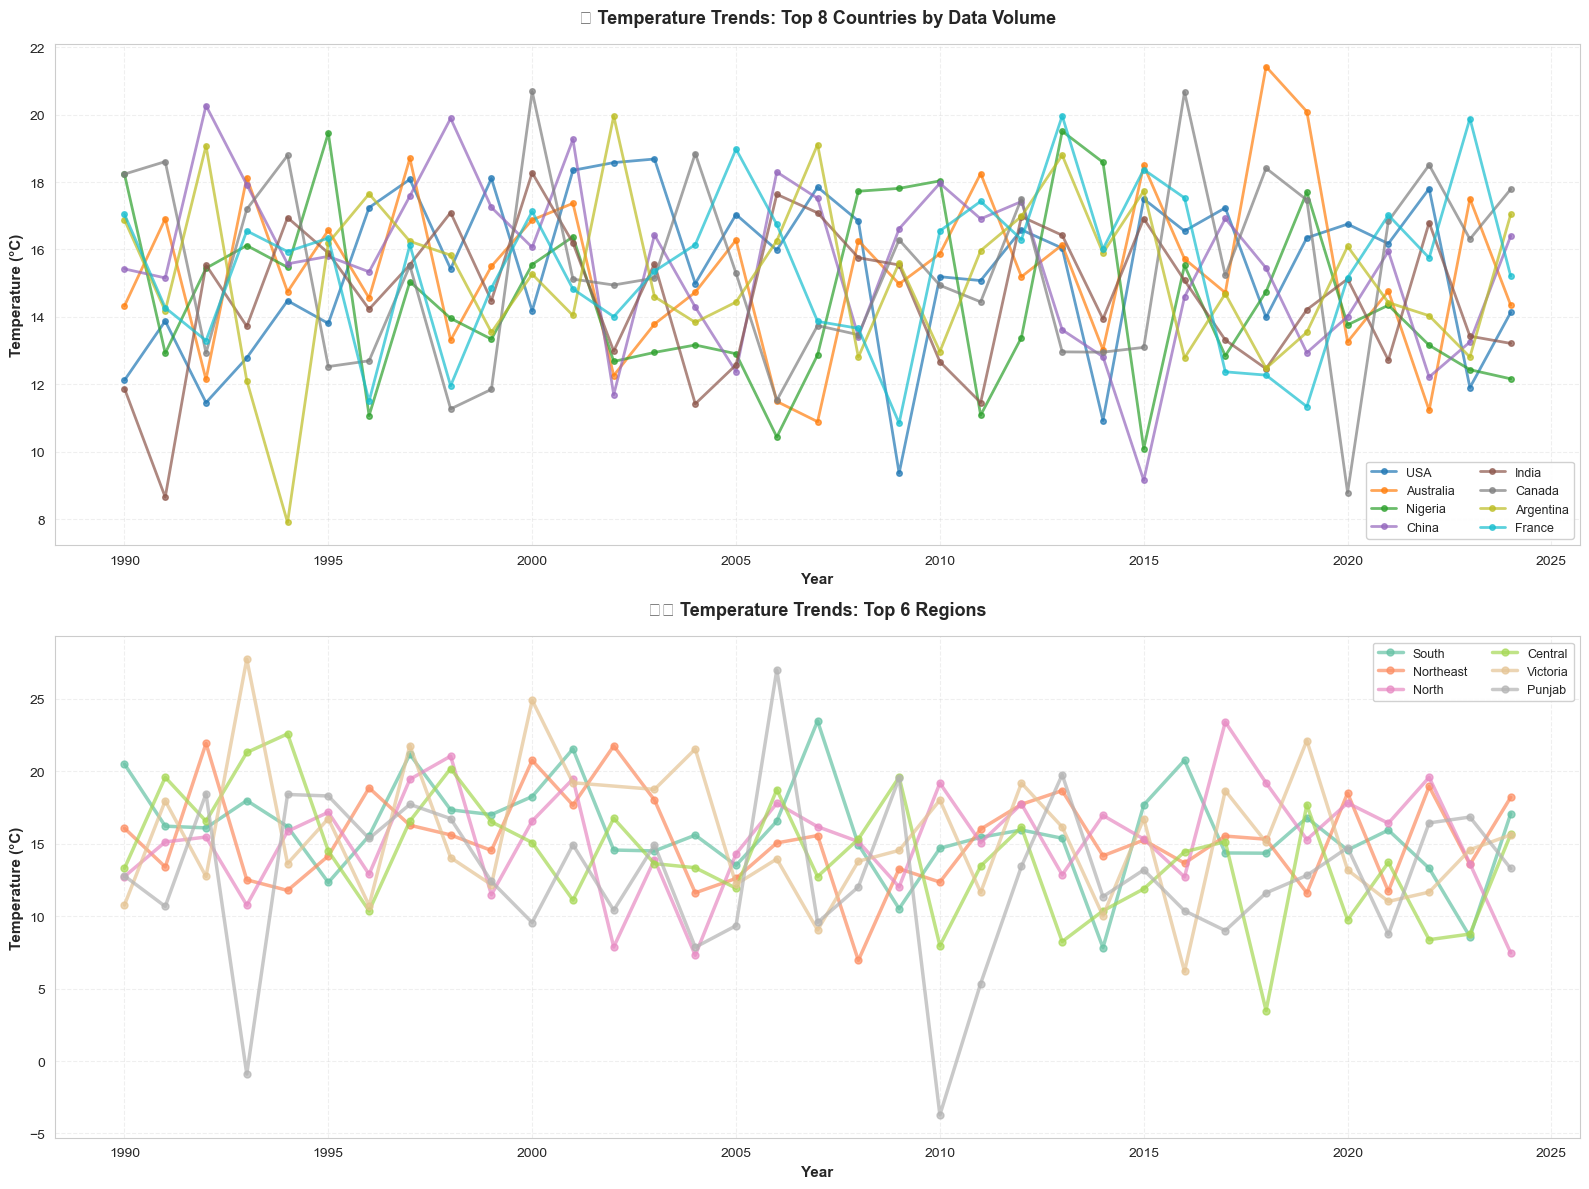


📊 Temperature Statistics by Top Countries:
   USA: Mean=15.65°C, Std=11.65°C
   Australia: Mean=15.33°C, Std=11.49°C
   Nigeria: Mean=14.58°C, Std=11.65°C
   China: Mean=15.51°C, Std=11.44°C
   India: Mean=14.56°C, Std=11.63°C
   Canada: Mean=15.55°C, Std=11.47°C
   Argentina: Mean=15.28°C, Std=11.07°C
   France: Mean=15.48°C, Std=11.46°C


In [3]:
# Compare temperature trends across different regions
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Top 8 Countries by data volume
print("🌍 Analyzing top countries by data volume...")
top_countries = df.groupby('Nama_Negara').size().nlargest(8).index
colors_countries = plt.cm.tab10(np.linspace(0, 1, len(top_countries)))

for i, country in enumerate(top_countries):
    country_data = df[df['Nama_Negara'] == country].groupby('Tahun')['Suhu_Rata_Rata_C'].mean()
    ax1.plot(country_data.index, country_data.values, 
             'o-', label=country, alpha=0.7, 
             linewidth=2, markersize=4, color=colors_countries[i])

ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax1.set_title('🌍 Temperature Trends: Top 8 Countries by Data Volume', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')

# Plot 2: Top 6 Regions
print("🗺️ Analyzing top regions...")
top_regions = df.groupby('Wilayah').size().nlargest(6).index
colors_regions = plt.cm.Set2(np.linspace(0, 1, len(top_regions)))

for i, region in enumerate(top_regions):
    region_data = df[df['Wilayah'] == region].groupby('Tahun')['Suhu_Rata_Rata_C'].mean()
    ax2.plot(region_data.index, region_data.values, 
             'o-', label=region[:30], alpha=0.7, 
             linewidth=2.5, markersize=5, color=colors_regions[i])

ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax2.set_title('🗺️ Temperature Trends: Top 6 Regions', 
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print statistics for top entities
print("\n📊 Temperature Statistics by Top Countries:")
for country in top_countries:
    country_temps = df[df['Nama_Negara'] == country]['Suhu_Rata_Rata_C']
    print(f"   {country}: Mean={country_temps.mean():.2f}°C, Std={country_temps.std():.2f}°C")

## 4. Seasonal Decomposition Visualization

🔄 Performing seasonal decomposition...


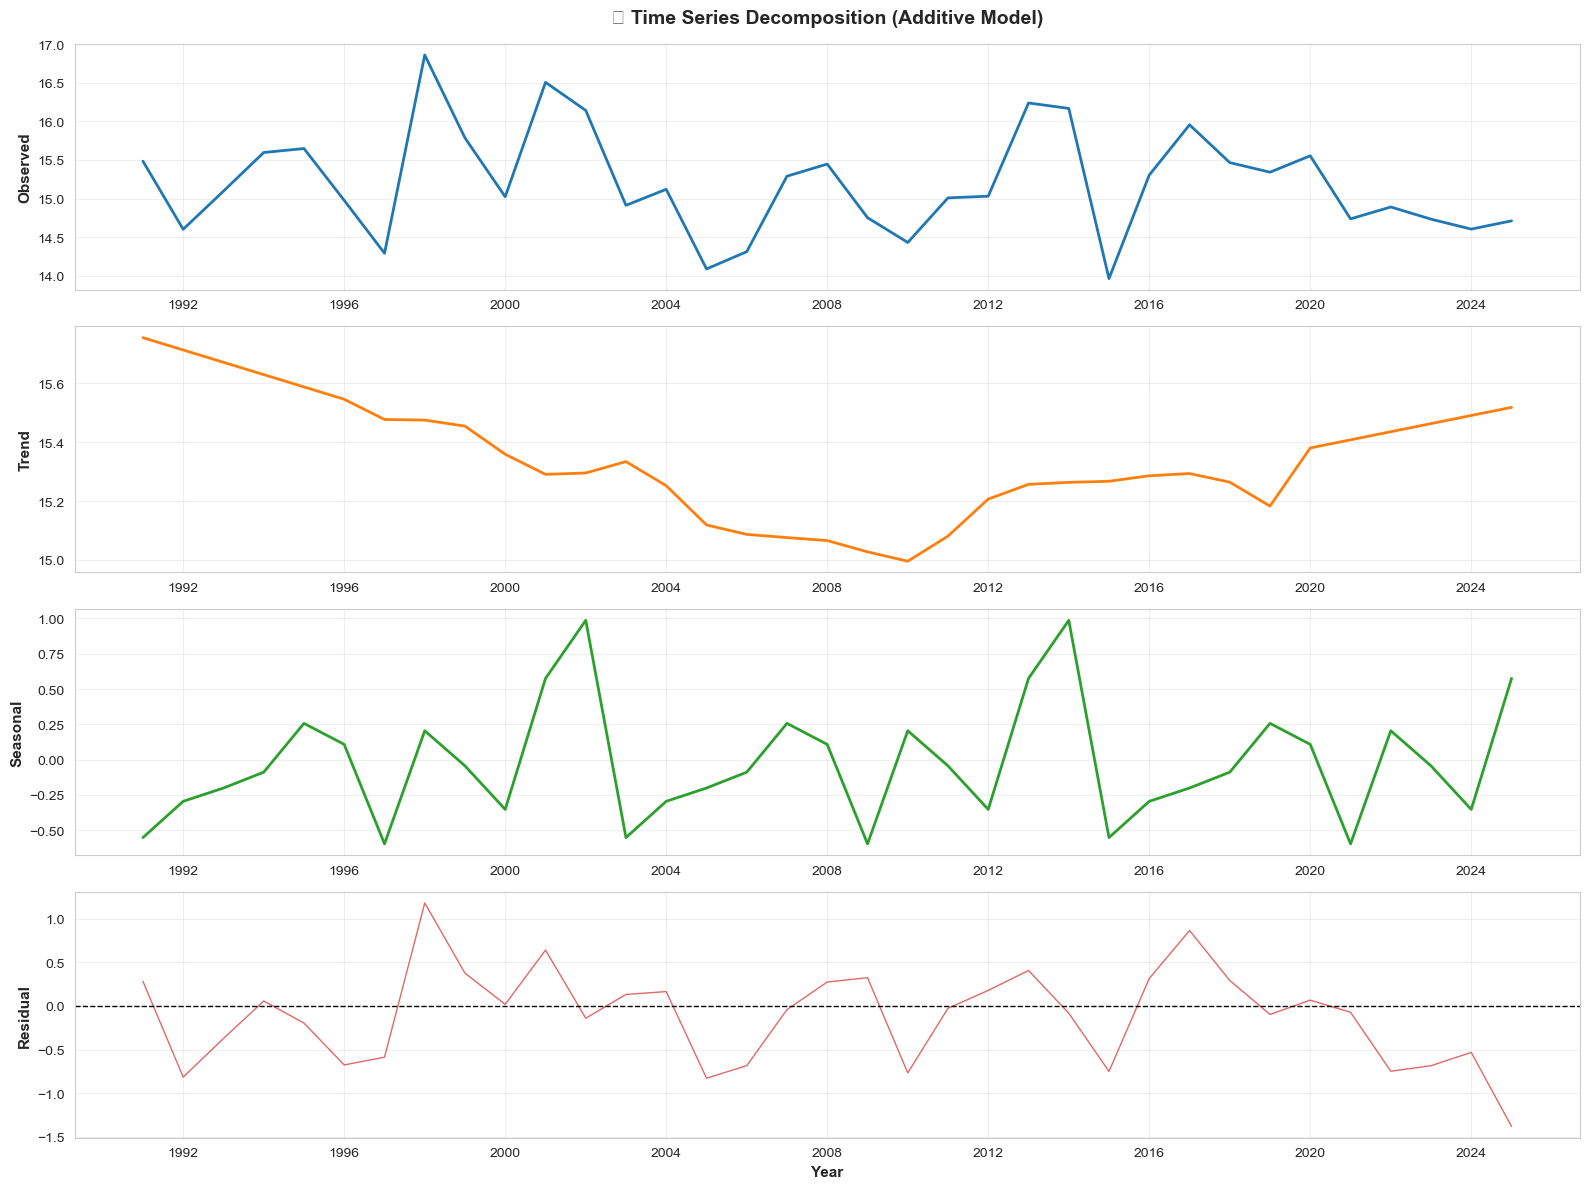


📈 Decomposition Statistics:
   Trend range: 15.00°C to 15.76°C
   Seasonal amplitude: 0.42°C
   Residual std: 0.55°C


In [4]:
# Prepare time series for decomposition
print("🔄 Performing seasonal decomposition...")

# Aggregate to yearly frequency for cleaner decomposition
ts_data = df.groupby('Tahun')['Suhu_Rata_Rata_C'].mean()
ts_series = pd.Series(ts_data.values, index=pd.date_range(start=f'{ts_data.index.min()}-01-01', 
                                                            periods=len(ts_data), freq='Y'))

# Perform seasonal decomposition
# Using a period that makes sense for the data
period = min(12, len(ts_series) // 2)  # Adaptive period
try:
    decomposition = seasonal_decompose(ts_series, model='additive', period=period, extrapolate_trend='freq')
    
    # Plot decomposition
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    
    # Original
    axes[0].plot(decomposition.observed, linewidth=2, color='#1f77b4')
    axes[0].set_ylabel('Observed', fontsize=11, fontweight='bold')
    axes[0].set_title('📊 Time Series Decomposition (Additive Model)', 
                      fontsize=14, fontweight='bold', pad=15)
    axes[0].grid(True, alpha=0.3)
    
    # Trend
    axes[1].plot(decomposition.trend, linewidth=2, color='#ff7f0e')
    axes[1].set_ylabel('Trend', fontsize=11, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Seasonal
    axes[2].plot(decomposition.seasonal, linewidth=2, color='#2ca02c')
    axes[2].set_ylabel('Seasonal', fontsize=11, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    # Residual
    axes[3].plot(decomposition.resid, linewidth=1, color='#d62728', alpha=0.7)
    axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[3].set_ylabel('Residual', fontsize=11, fontweight='bold')
    axes[3].set_xlabel('Year', fontsize=11, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print decomposition statistics
    print(f"\n📈 Decomposition Statistics:")
    print(f"   Trend range: {decomposition.trend.min():.2f}°C to {decomposition.trend.max():.2f}°C")
    print(f"   Seasonal amplitude: {decomposition.seasonal.std():.2f}°C")
    print(f"   Residual std: {decomposition.resid.std():.2f}°C")
    
except Exception as e:
    print(f"⚠️ Could not perform seasonal decomposition: {e}")
    print(f"   Data length: {len(ts_series)}, Period used: {period}")

## 5. Rolling Statistics Visualization

📊 Calculating rolling statistics...


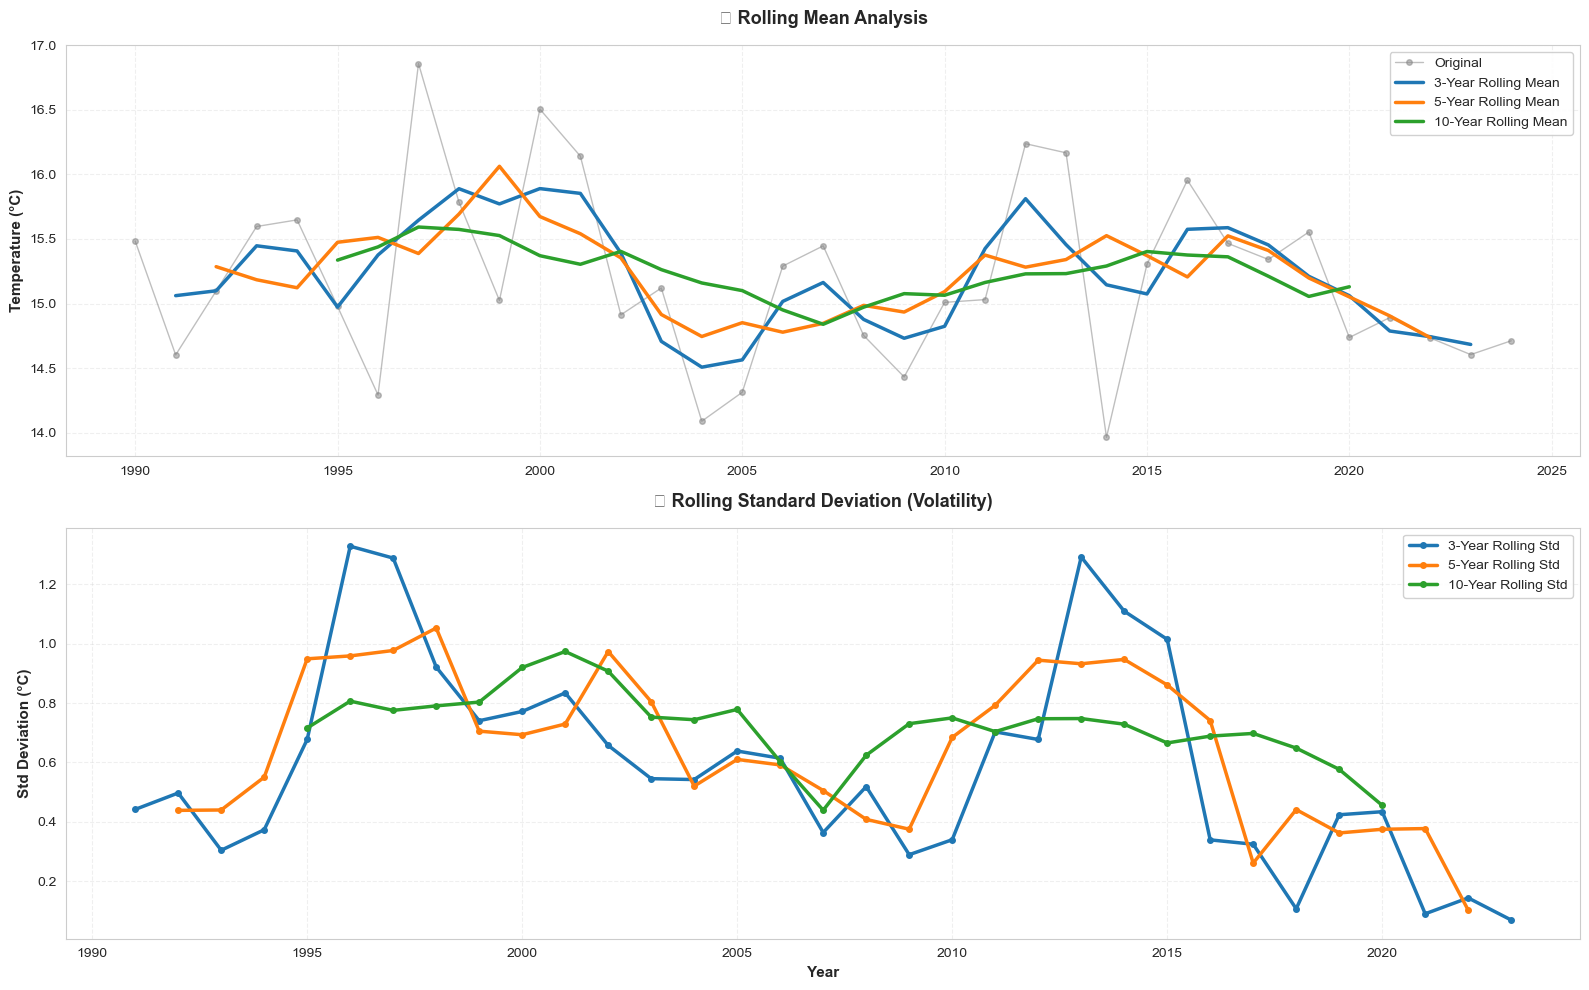


📊 Volatility Analysis:
   3-Year Rolling Std: Mean=0.588°C, Max=1.328°C
   5-Year Rolling Std: Mean=0.648°C, Max=1.053°C
   10-Year Rolling Std: Mean=0.722°C, Max=0.974°C


In [5]:
# Calculate rolling statistics
print("📊 Calculating rolling statistics...")

# Define window sizes
windows = [3, 5, 10]  # Years

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Prepare data
yearly_temp_series = df.groupby('Tahun')['Suhu_Rata_Rata_C'].mean()

# Plot 1: Rolling Mean
axes[0].plot(yearly_temp_series.index, yearly_temp_series.values, 
             'o-', linewidth=1, markersize=4, label='Original', 
             color='gray', alpha=0.5)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, window in enumerate(windows):
    rolling_mean = yearly_temp_series.rolling(window=window, center=True).mean()
    axes[0].plot(rolling_mean.index, rolling_mean.values, 
                 linewidth=2.5, label=f'{window}-Year Rolling Mean', 
                 color=colors[i])

axes[0].set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
axes[0].set_title('📈 Rolling Mean Analysis', fontsize=13, fontweight='bold', pad=15)
axes[0].legend(loc='best', fontsize=10, framealpha=0.9)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Plot 2: Rolling Standard Deviation (Volatility)
for i, window in enumerate(windows):
    rolling_std = yearly_temp_series.rolling(window=window, center=True).std()
    axes[1].plot(rolling_std.index, rolling_std.values, 
                 'o-', linewidth=2.5, markersize=4,
                 label=f'{window}-Year Rolling Std', 
                 color=colors[i])

axes[1].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Std Deviation (°C)', fontsize=11, fontweight='bold')
axes[1].set_title('📊 Rolling Standard Deviation (Volatility)', 
                  fontsize=13, fontweight='bold', pad=15)
axes[1].legend(loc='best', fontsize=10, framealpha=0.9)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Calculate and display volatility metrics
print(f"\n📊 Volatility Analysis:")
for window in windows:
    rolling_std = yearly_temp_series.rolling(window=window).std()
    print(f"   {window}-Year Rolling Std: Mean={rolling_std.mean():.3f}°C, Max={rolling_std.max():.3f}°C")

## 6. Interactive Time Series Plot with Plotly

In [6]:
# Create interactive visualization with Plotly
print("🎨 Creating interactive visualization...")

# Prepare aggregated data
yearly_stats = df.groupby('Tahun').agg({
    'Suhu_Rata_Rata_C': ['mean', 'min', 'max', 'std', 'count']
}).reset_index()
yearly_stats.columns = ['Year', 'Mean', 'Min', 'Max', 'Std', 'Count']

# Calculate rolling averages
yearly_stats['MA_3'] = yearly_stats['Mean'].rolling(window=3, center=True).mean()
yearly_stats['MA_5'] = yearly_stats['Mean'].rolling(window=5, center=True).mean()

# Create subplot figure
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=(
        '🌡️ Temperature Trends with Moving Averages',
        '📊 Temperature Range (Min-Max)',
        '📈 Data Point Count per Year'
    ),
    vertical_spacing=0.1,
    row_heights=[0.5, 0.25, 0.25]
)

# Plot 1: Main temperature with moving averages
fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['Mean'],
        mode='lines+markers',
        name='Mean Temperature',
        line=dict(color='#d62728', width=2),
        marker=dict(size=6),
        hovertemplate='<b>Year:</b> %{x}<br><b>Mean:</b> %{y:.2f}°C<br><extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['MA_3'],
        mode='lines',
        name='3-Year MA',
        line=dict(color='#1f77b4', width=2, dash='dash'),
        hovertemplate='<b>Year:</b> %{x}<br><b>3-Year MA:</b> %{y:.2f}°C<br><extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['MA_5'],
        mode='lines',
        name='5-Year MA',
        line=dict(color='#2ca02c', width=2, dash='dot'),
        hovertemplate='<b>Year:</b> %{x}<br><b>5-Year MA:</b> %{y:.2f}°C<br><extra></extra>'
    ),
    row=1, col=1
)

# Plot 2: Min-Max Range
fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['Max'],
        mode='lines',
        name='Max',
        line=dict(width=0),
        showlegend=False,
        hoverinfo='skip'
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['Min'],
        mode='lines',
        name='Min-Max Range',
        line=dict(width=0),
        fillcolor='rgba(255, 127, 14, 0.3)',
        fill='tonexty',
        hovertemplate='<b>Year:</b> %{x}<br><b>Min:</b> %{y:.2f}°C<br><extra></extra>'
    ),
    row=2, col=1
)

# Plot 3: Data count
fig.add_trace(
    go.Bar(
        x=yearly_stats['Year'],
        y=yearly_stats['Count'],
        name='Data Points',
        marker_color='lightblue',
        hovertemplate='<b>Year:</b> %{x}<br><b>Count:</b> %{y}<br><extra></extra>'
    ),
    row=3, col=1
)

# Update layout
fig.update_layout(
    height=1000,
    title_text="<b>Interactive Time Series Dashboard</b>",
    title_font_size=18,
    showlegend=True,
    hovermode='x unified',
    template='plotly_white'
)

fig.update_xaxes(title_text="Year", row=3, col=1)
fig.update_yaxes(title_text="Temperature (°C)", row=1, col=1)
fig.update_yaxes(title_text="Temperature (°C)", row=2, col=1)
fig.update_yaxes(title_text="Count", row=3, col=1)

fig.show()

print("✅ Interactive plot created! Use the toolbar to zoom, pan, and explore the data.")

🎨 Creating interactive visualization...


✅ Interactive plot created! Use the toolbar to zoom, pan, and explore the data.


## 7. Autocorrelation and Partial Autocorrelation Plots

🔄 Analyzing autocorrelation patterns...


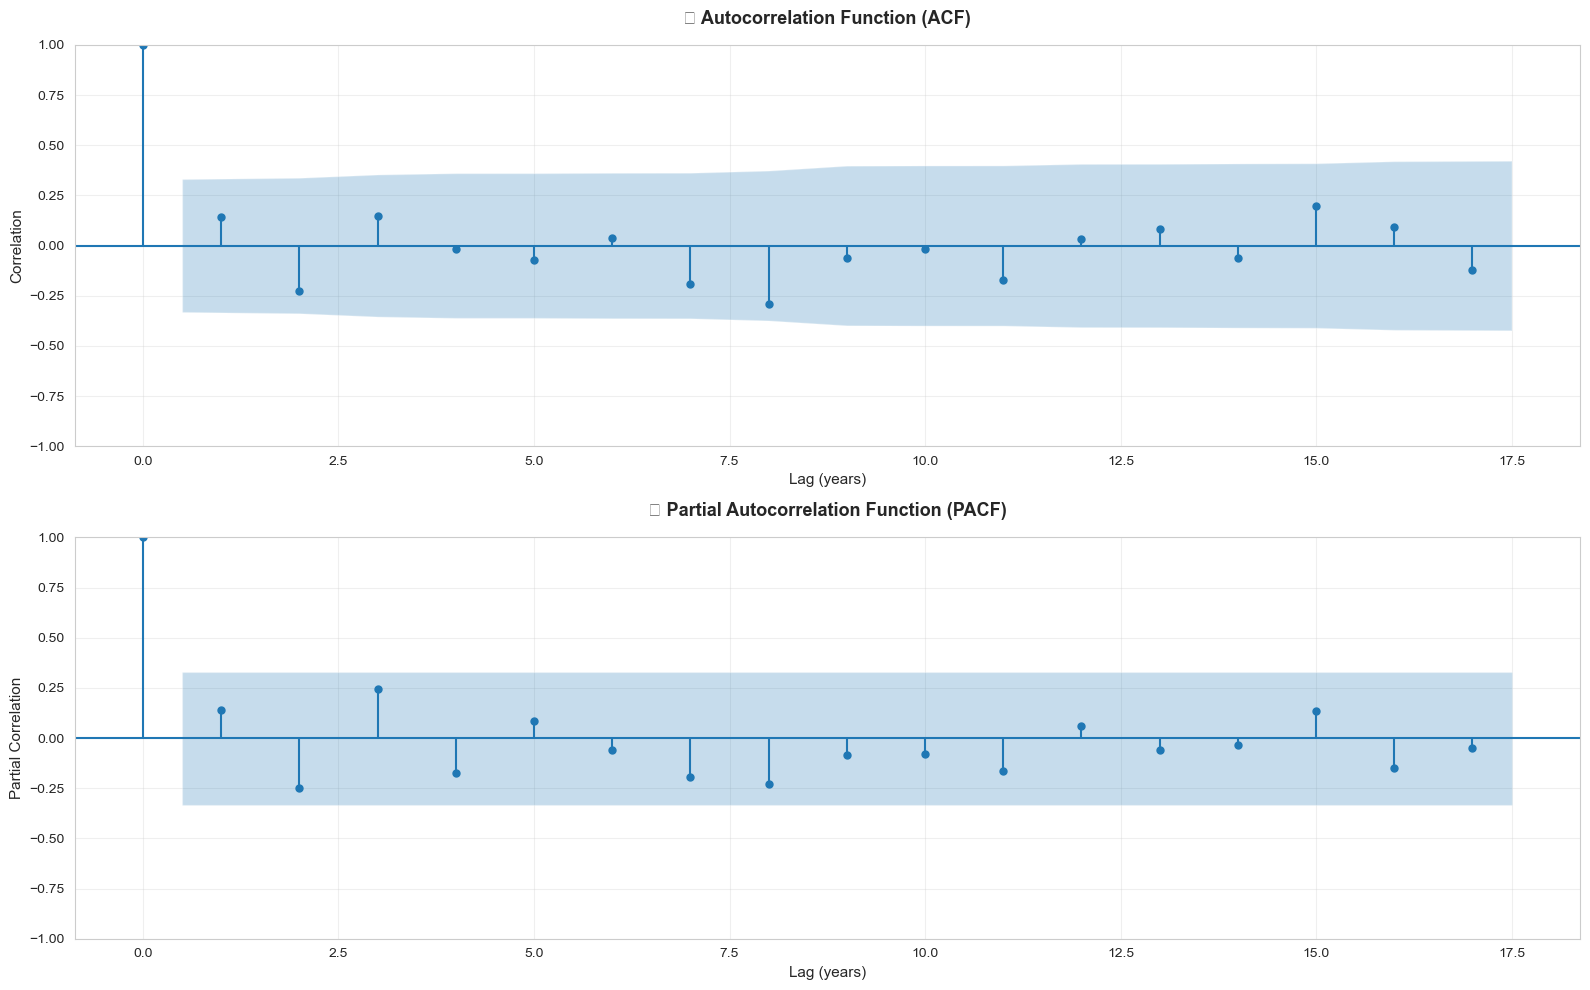


📈 Autocorrelation Analysis:
   95% Confidence Interval: ±0.331
   Significant lag 8: -0.358
   Significant lag 15: 0.372
   Significant lag 18: 0.527
   Significant lag 19: 0.484


In [7]:
# ACF and PACF analysis
print("🔄 Analyzing autocorrelation patterns...")

# Prepare time series
ts_data = df.groupby('Tahun')['Suhu_Rata_Rata_C'].mean()

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Calculate appropriate lag limit
max_lags = min(40, len(ts_data) // 2)

# Plot ACF
plot_acf(ts_data, lags=max_lags, ax=axes[0], alpha=0.05)
axes[0].set_title('📊 Autocorrelation Function (ACF)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Lag (years)', fontsize=11)
axes[0].set_ylabel('Correlation', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot PACF
plot_pacf(ts_data, lags=max_lags, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('📊 Partial Autocorrelation Function (PACF)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Lag (years)', fontsize=11)
axes[1].set_ylabel('Partial Correlation', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find significant lags
from scipy import stats as scipy_stats
n = len(ts_data)
confidence_interval = 1.96 / np.sqrt(n)

print(f"\n📈 Autocorrelation Analysis:")
print(f"   95% Confidence Interval: ±{confidence_interval:.3f}")

# Compute ACF values manually for analysis
acf_values = []
for lag in range(1, min(20, len(ts_data))):
    if lag < len(ts_data):
        corr = np.corrcoef(ts_data.values[:-lag], ts_data.values[lag:])[0, 1]
        acf_values.append((lag, corr))
        if abs(corr) > confidence_interval:
            print(f"   Significant lag {lag}: {corr:.3f}")

if not any(abs(c) > confidence_interval for _, c in acf_values):
    print("   No significant autocorrelation detected beyond 95% confidence interval")

## 8. Heatmap for Temporal Patterns

🔥 Creating temporal pattern heatmaps...
   Creating Year × Country heatmap...
   Creating Year × Region heatmap...


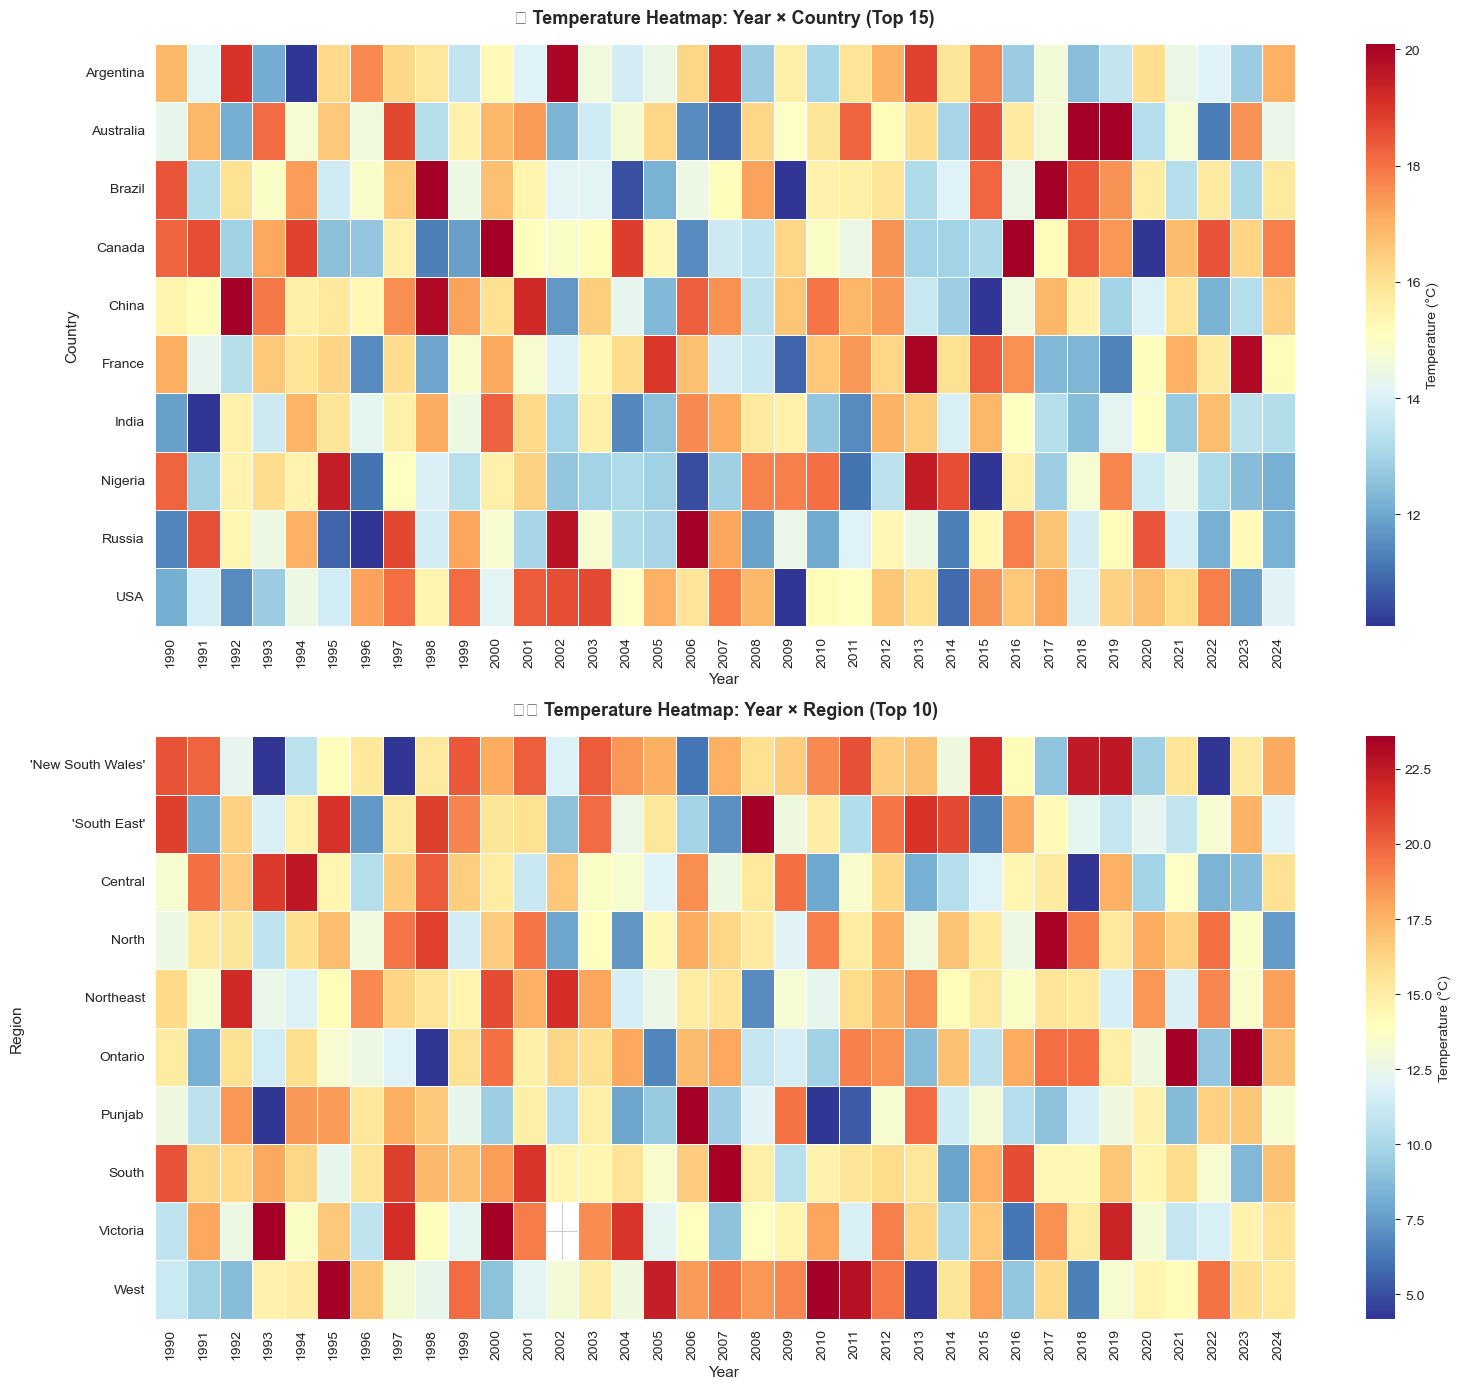


📊 Heatmap Statistics:
   Country heatmap: 10 countries × 35 years
   Temperature range: 7.90°C to 21.43°C
   Region heatmap: 10 regions × 35 years
   Temperature range: -3.72°C to 33.08°C


In [8]:
# Create heatmaps for temporal patterns
print("🔥 Creating temporal pattern heatmaps...")

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Heatmap 1: Year × Country (Top 15 countries)
print("   Creating Year × Country heatmap...")
top_countries = df.groupby('Nama_Negara').size().nlargest(15).index
pivot_country = df[df['Nama_Negara'].isin(top_countries)].pivot_table(
    values='Suhu_Rata_Rata_C',
    index='Nama_Negara',
    columns='Tahun',
    aggfunc='mean'
)

sns.heatmap(pivot_country, cmap='RdYlBu_r', cbar_kws={'label': 'Temperature (°C)'},
            ax=axes[0], linewidths=0.5, linecolor='white', 
            robust=True, fmt='.1f', annot=False)
axes[0].set_title('🌍 Temperature Heatmap: Year × Country (Top 15)', 
                  fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Country', fontsize=11)

# Heatmap 2: Year × Region (Top 10 regions)
print("   Creating Year × Region heatmap...")
top_regions = df.groupby('Wilayah').size().nlargest(10).index
pivot_region = df[df['Wilayah'].isin(top_regions)].pivot_table(
    values='Suhu_Rata_Rata_C',
    index='Wilayah',
    columns='Tahun',
    aggfunc='mean'
)

sns.heatmap(pivot_region, cmap='RdYlBu_r', cbar_kws={'label': 'Temperature (°C)'},
            ax=axes[1], linewidths=0.5, linecolor='white',
            robust=True, fmt='.1f', annot=False)
axes[1].set_title('🗺️ Temperature Heatmap: Year × Region (Top 10)', 
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Region', fontsize=11)

plt.tight_layout()
plt.show()

# Print heatmap statistics
print(f"\n📊 Heatmap Statistics:")
print(f"   Country heatmap: {pivot_country.shape[0]} countries × {pivot_country.shape[1]} years")
print(f"   Temperature range: {pivot_country.min().min():.2f}°C to {pivot_country.max().max():.2f}°C")
print(f"   Region heatmap: {pivot_region.shape[0]} regions × {pivot_region.shape[1]} years")
print(f"   Temperature range: {pivot_region.min().min():.2f}°C to {pivot_region.max().max():.2f}°C")

## Summary

This notebook provides comprehensive visualizations for time series analysis:

1. ✅ **Basic Line Plots**: Simple trend visualization with confidence bands
2. ✅ **Multi-series Comparison**: Compare trends across countries and regions
3. ✅ **Seasonal Decomposition**: Break down into trend, seasonal, and residual components
4. ✅ **Rolling Statistics**: Identify trends and volatility patterns
5. ✅ **Interactive Plotly Charts**: Explore data with zoom and hover capabilities
6. ✅ **ACF/PACF Analysis**: Detect autocorrelation and seasonal patterns
7. ✅ **Temporal Heatmaps**: Visualize patterns across time and spatial dimensions

All visualizations are ready for inclusion in your paper or presentation! 📊